For Week 11, include concepts such as density-based spatial clustering of applications with noise (DBSCAN), hierarchical agglomerative clustering (HAC), linkage methods in HAC, and dendrograms. Complete your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import gower

In [2]:
random_state = 42

## ECC

### Import Dataset

In [3]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
# Identify all float64 columns
float64_cols = df.select_dtypes(include=['float64']).columns

# Convert only those columns to float32
df[float64_cols] = df[float64_cols].astype('float32')

In [5]:
df.dtypes

Time      float32
V1        float32
V2        float32
V3        float32
V4        float32
V5        float32
V6        float32
V7        float32
V8        float32
V9        float32
V10       float32
V11       float32
V12       float32
V13       float32
V14       float32
V15       float32
V16       float32
V17       float32
V18       float32
V19       float32
V20       float32
V21       float32
V22       float32
V23       float32
V24       float32
V25       float32
V26       float32
V27       float32
V28       float32
Amount    float32
Class       int64
dtype: object

In [6]:
X = df.drop(columns='Class')
y = df['Class']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 284315, 1: 492})
Resampled dataset shape: Counter({0: 49200, 1: 492})


### Split Data

### Scaling

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### DBScan

In [8]:
min_samples = 2 * len(X.columns) # 2*D to avoid clustering marking sparse regions as valid clusters. With a value of 3 I found 1800 clusters
min_samples

60

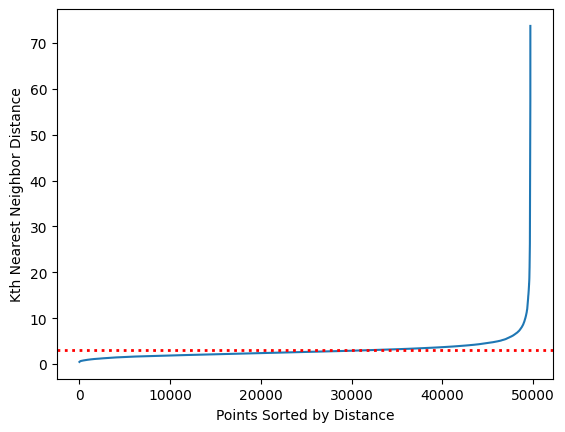

In [ ]:
# 1. Set k to your min_samples value
k = min_samples

# 2. Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# 3. Sort distances by the k-th neighbor column (index k-1)
sorted_distances = np.sort(distances[:, k-1])

# 4. Plot to find the Epsilon elbow
plt.plot(sorted_distances)
plt.ylabel("Kth Nearest Neighbor Distance")
plt.xlabel("Points Sorted by Distance")
plt.axhline(y=5.5, linestyle=':', color='red', linewidth=2)
None

In [63]:
eps = 5.5 # Based on the curve, 5.5 looks to be where the elbow is

In [64]:
clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)

In [65]:
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 1
Estimated number of noise points: 1392


In [66]:
# Convert X to pandas df for easier aggregation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns).copy()

In [67]:
# Combine cluster labels and target variable into a single summary DataFrame
summary_df = pd.DataFrame({"cluster": labels, "target": y_resampled})

In [68]:
# --- 3. Aggregate Cluster Statistics ---
cluster_stats = (
    summary_df.groupby("cluster")
    .agg(
        cluster_size=("target", "count"),
        positive_count=("target", "sum"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

In [69]:
# Global metrics for context
global_pos_rate = y.mean()
print(f"Total Data Points: {len(X_scaled_df)}")
print(f"Global Positive Rate: {global_pos_rate:.4f}")
print(
    f"Number of Clusters (excluding noise): {len(set(labels)) - (1 if -1 in labels else 0)}"
)

Total Data Points: 49692
Global Positive Rate: 0.0017
Number of Clusters (excluding noise): 1


In [70]:
# --- 4. Identify Target-Rich Clusters ---
# Sort by highest concentration of your positive target class
high_purity_clusters = cluster_stats.sort_values(
    by="positive_rate", ascending=False
).head(10)
print("\n--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---")
print(high_purity_clusters.to_string(index=False))


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
      -1          1392             407       0.292385
       0         48300              85       0.001760


In [72]:
# --- 5. Identify Popular Clusters ---
# Sort by size to find the largest groups (excluding noise cluster -1)
popular_clusters = (
    cluster_stats[cluster_stats["cluster"] != -1]
    .sort_values(by="cluster_size", ascending=False)
    .head(10)
)
print("\n--- TOP 10 LARGEST VALID CLUSTERS ---")
print(popular_clusters.to_string(index=False))


--- TOP 10 LARGEST VALID CLUSTERS ---
 cluster  cluster_size  positive_count  positive_rate
       0         48300              85        0.00176


In [73]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = popular_clusters.iloc[0]["cluster"]

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 0.0 ---
        Cluster Mean   Global Mean  Difference
Time        0.002524 -6.448414e-09    0.002524
V1          0.087143  0.000000e+00    0.087143
V2          0.005336  0.000000e+00    0.005336
V3          0.063728  7.369616e-09    0.063728
V4         -0.039517 -2.456539e-09   -0.039517
V5          0.023905 -4.913077e-09    0.023905
V6          0.004614  4.913077e-09    0.004614
V7          0.049515 -2.456539e-09    0.049515
V8          0.033425 -1.228269e-09    0.033425
V9          0.005055  2.456539e-09    0.005055
V10         0.024025 -4.913077e-09    0.024025
V11        -0.037109 -1.228269e-08   -0.037109
V12         0.045898  0.000000e+00    0.045898
V13        -0.001878 -4.068642e-09   -0.001878
V14         0.056352  0.000000e+00    0.056352
V15        -0.003500 -1.136149e-08   -0.003500
V16         0.037666  4.913077e-09    0.037666
V17         0.053397  9.826154e-09    0.053397
V18         0.027685 -2.456539e-09    0.027685
V19        

In [74]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 0.0 ---
|--- V1 <= -2.40
|   |--- V1 <= -3.47
|   |   |--- V14 <= 1.85
|   |   |   |--- class: 0
|   |   |--- V14 >  1.85
|   |   |   |--- class: 0
|   |--- V1 >  -3.47
|   |   |--- V8 <= 0.54
|   |   |   |--- class: 0
|   |   |--- V8 >  0.54
|   |   |   |--- class: 1
|--- V1 >  -2.40
|   |--- V17 <= -1.63
|   |   |--- V16 <= -0.55
|   |   |   |--- class: 0
|   |   |--- V16 >  -0.55
|   |   |   |--- class: 1
|   |--- V17 >  -1.63
|   |   |--- V8 <= -4.58
|   |   |   |--- class: 0
|   |   |--- V8 >  -4.58
|   |   |   |--- class: 1



## IBM

### Import Dataset

In [3]:
df = pd.read_csv("C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ibm_hi_small_trans_cleaned.csv")
cols_to_drop = [c for c in df.columns if "_Mean" in c or "_Median" in c]
cols_to_drop.append('Timestamp')
cols_to_drop.append('Account')
cols_to_drop.append('Account.1')
cols_to_drop.append('From Bank')
cols_to_drop.append('To Bank')

df.drop(columns=cols_to_drop, inplace=True)
df

,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,3697.340000,3697.340000,0,3697.340000,3697.340000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,0.010000,0.010000,0,0.010000,0.010000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,14675.570000,14675.570000,0,14675.570000,14675.570000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,2806.970000,2806.970000,0,2806.970000,2806.970000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,36682.970000,36682.970000,0,36682.970000,36682.970000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,0.154978,0.154978,0,3107.386389,3107.386389,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,0.108128,0.108128,0,2168.020464,2168.020464,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,0.004988,0.004988,0,100.011894,100.011894,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,0.038417,0.038417,0,770.280058,770.280058,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


In [4]:
X = df.drop(columns='Is Laundering')
y = df['Is Laundering']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 5073168, 1: 5177})
Resampled dataset shape: Counter({0: 51770, 1: 5177})


### Scaling

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### DBScan

In [6]:
min_samples = 2 * len(X.columns) # 2*D to avoid clustering marking sparse regions as valid clusters. With a value of 3 I found 1800 clusters
min_samples

86

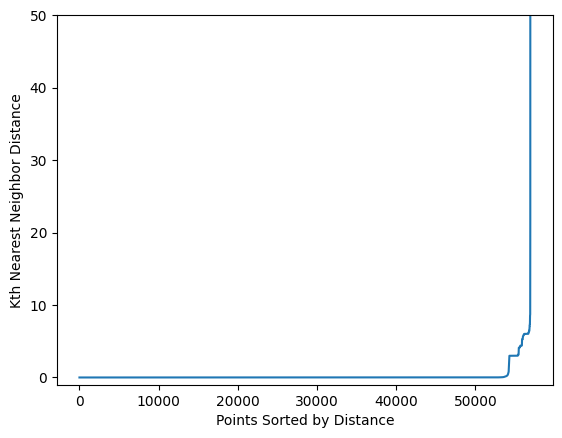

In [12]:
# 1. Set k to your min_samples value
k = min_samples

# 2. Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# 3. Sort distances by the k-th neighbor column (index k-1)
sorted_distances = np.sort(distances[:, k-1])

# 4. Plot to find the Epsilon elbow
plt.plot(sorted_distances)
plt.ylabel("Kth Nearest Neighbor Distance")
plt.xlabel("Points Sorted by Distance")
plt.ylim(bottom=-1, top=50)
# plt.axhline(y=5.8, linestyle=':', color='red', linewidth=2)
None

In [13]:
from kneed import KneeLocator

# Find the elbow point automatically
i = np.arange(len(sorted_distances))
knee = KneeLocator(i, sorted_distances, S=1.0, curve='convex', direction='increasing')

optimal_eps = sorted_distances[knee.knee]
print(f"Estimated Epsilon: {optimal_eps}")

Estimated Epsilon: 8.70023607453561


In [14]:
"""
I initially tried 8.7 but it resulted in the following breakdown of clusters:

--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
      -1            13               6       0.461538
       0         55377            5115       0.092367
       1          1557              56       0.035967

The positive class are clearly hidden in the large cluster. I hypothesize the mixed data (mostly binary and some numeric is causing issues for euclidian distance)
I will try use gower instead which handles mixed types
"""
eps = optimal_eps

In [8]:
# 1. Compute the custom distance matrix across your mixed data
# (Expects a pandas DataFrame or numpy array where columns are mixed)
distance_matrix = gower.gower_matrix(X_scaled)

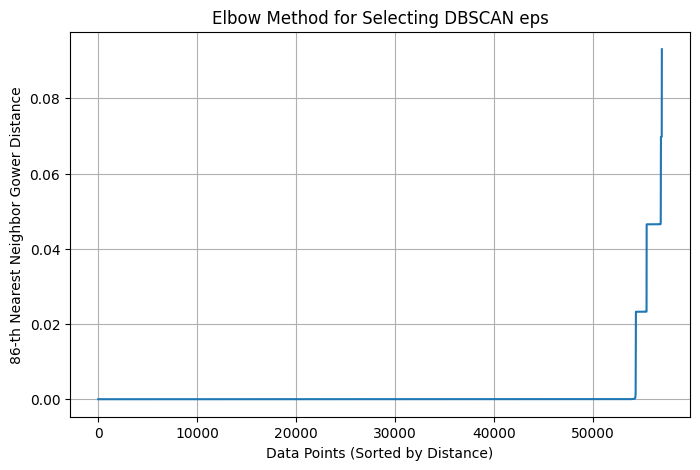

In [17]:

# Fit NearestNeighbors using the 'precomputed' Gower matrix
# We use k+1 because the closest neighbor to any point is always itself (distance 0)
neighbors = NearestNeighbors(n_neighbors=k+1, metric='precomputed')
neighbors_fit = neighbors.fit(distance_matrix)
distances, indices = neighbors_fit.kneighbors(distance_matrix)

# Grab the distance to the k-th nearest neighbor and sort
k_distances = np.sort(distances[:, k])

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Data Points (Sorted by Distance)')
plt.ylabel(f'{k}-th Nearest Neighbor Gower Distance')
plt.title('Elbow Method for Selecting DBSCAN eps')
plt.grid(True)
None

In [65]:
# clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
clustering = DBSCAN(eps=0.025, min_samples=min_samples, metric='precomputed').fit(distance_matrix)

In [66]:
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 75
Estimated number of noise points: 1212


In [67]:
# Convert X to pandas df for easier aggregation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns).copy()

In [68]:
# Combine cluster labels and target variable into a single summary DataFrame
summary_df = pd.DataFrame({"cluster": labels, "target": y_resampled})

In [69]:
# --- 3. Aggregate Cluster Statistics ---
cluster_stats = (
    summary_df.groupby("cluster")
    .agg(
        cluster_size=("target", "count"),
        positive_count=("target", "sum"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

In [70]:
# Global metrics for context
global_pos_rate = y.mean()
print(f"Total Data Points: {len(X_scaled_df)}")
print(f"Global Positive Rate: {global_pos_rate:.4f}")
print(
    f"Number of Clusters (excluding noise): {len(set(labels)) - (1 if -1 in labels else 0)}"
)

Total Data Points: 56947
Global Positive Rate: 0.0010
Number of Clusters (excluding noise): 75


In [71]:
# --- 4. Identify Target-Rich Clusters ---
# Sort by highest concentration of your positive target class
high_purity_clusters = cluster_stats.sort_values(
    by="positive_rate", ascending=False
).head(10)
print("\n--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---")
print(high_purity_clusters.to_string(index=False))


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
      65           470             361       0.768085
      13          2421            1206       0.498141
       2           347             162       0.466859
      26          3665            1663       0.453752
      45           299             132       0.441472
      54           193              79       0.409326
       5           356             144       0.404494
      61           278             112       0.402878
      29           282             111       0.393617
      46           290             114       0.393103


In [74]:
# --- 5. Identify Popular Clusters ---
# Sort by size to find the largest groups (excluding noise cluster -1)
popular_clusters = (
    cluster_stats[cluster_stats["cluster"] != -1]
    .sort_values(by="cluster_size", ascending=False)
    .head(10)
)
print("\n--- TOP 10 LARGEST VALID CLUSTERS ---")
print(popular_clusters.to_string(index=False))


--- TOP 10 LARGEST VALID CLUSTERS ---
 cluster  cluster_size  positive_count  positive_rate
      10          7328             120       0.016376
       1          5197              90       0.017318
       7          4710              91       0.019321
      26          3665            1663       0.453752
      14          3282              52       0.015844
      13          2421            1206       0.498141
      12          1872              39       0.020833
      18          1855               0       0.000000
      16          1557              56       0.035967
      21          1193               0       0.000000


In [75]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = popular_clusters.iloc[0]["cluster"]

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 10.0 ---
                                      Cluster Mean   Global Mean  Difference
Amount Received                          -0.012511  9.981811e-19   -0.012511
Amount Paid                              -0.011658 -9.981811e-19   -0.011658
Amount_Received_USD                      -0.006843 -9.981811e-19   -0.006843
Amount_Paid_USD                          -0.006840  0.000000e+00   -0.006840
Receiving Currency_Australian Dollar     -0.172631 -6.787631e-17   -0.172631
Receiving Currency_Bitcoin               -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real           -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar       -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                  -0.553907  9.981811e-19   -0.553907
Receiving Currency_Mexican Peso          -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble                 -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee  

In [79]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 10.0 ---
|--- Payment Format_Cheque <= 0.33
|   |--- class: 0
|--- Payment Format_Cheque >  0.33
|   |--- Receiving Currency_US Dollar <= 0.28
|   |   |--- class: 0
|   |--- Receiving Currency_US Dollar >  0.28
|   |   |--- class: 1



In [80]:
# Profiling the cluster with many positive class
target_cluster_id = 65

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 65 ---
                                      Cluster Mean   Global Mean  Difference
Amount Received                           0.000419  9.981811e-19    0.000419
Amount Paid                               0.001306 -9.981811e-19    0.001306
Amount_Received_USD                       0.013846 -9.981811e-19    0.013846
Amount_Paid_USD                           0.013849  0.000000e+00    0.013849
Receiving Currency_Australian Dollar     -0.172631 -6.787631e-17   -0.172631
Receiving Currency_Bitcoin               -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real           -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar       -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                  -0.553907  9.981811e-19   -0.553907
Receiving Currency_Mexican Peso          -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble                 -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee    

In [81]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 65 ---
|--- Payment Currency_Saudi Riyal <= 3.23
|   |--- class: 0
|--- Payment Currency_Saudi Riyal >  3.23
|   |--- Payment Format_ACH <= 0.81
|   |   |--- class: 0
|   |--- Payment Format_ACH >  0.81
|   |   |--- Receiving Currency_US Dollar <= 0.28
|   |   |   |--- class: 1
|   |   |--- Receiving Currency_US Dollar >  0.28
|   |   |   |--- class: 0



In [82]:
# Profiling the cluster with many positive class
target_cluster_id = 13

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 13 ---
                                      Cluster Mean   Global Mean  Difference
Amount Received                          -0.011887  9.981811e-19   -0.011887
Amount Paid                              -0.011032 -9.981811e-19   -0.011032
Amount_Received_USD                      -0.002663 -9.981811e-19   -0.002663
Amount_Paid_USD                          -0.002660  0.000000e+00   -0.002660
Receiving Currency_Australian Dollar     -0.172631 -6.787631e-17   -0.172631
Receiving Currency_Bitcoin               -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real           -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar       -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                   1.805356  9.981811e-19    1.805356
Receiving Currency_Mexican Peso          -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble                 -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee    

In [83]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 13 ---
|--- Payment Format_ACH <= 0.81
|   |--- class: 0
|--- Payment Format_ACH >  0.81
|   |--- Payment Currency_Euro <= 0.63
|   |   |--- class: 0
|   |--- Payment Currency_Euro >  0.63
|   |   |--- Receiving Currency_Euro <= 0.63
|   |   |   |--- class: 0
|   |   |--- Receiving Currency_Euro >  0.63
|   |   |   |--- class: 1



## PPP

### Import Dataset

In [3]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ppp_cleaned.csv')
df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,0.0,48.0,2.0,24,769358.78,769358.78,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12409.01,0,1588291200,1605830400,1608249600
1,0.0,48.0,2.0,24,736927.79,736927.79,11.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10094.90,0,1588291200,1628726400,1632787200
2,0.0,48.0,2.0,24,691355.00,691355.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9218.07,0,1588291200,1612915200,1615939200
3,0.0,48.0,2.0,24,499871.00,499871.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,23803.38,0,1588291200,1631232000,1634342400
4,0.0,48.0,2.0,24,367437.00,367437.00,37.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,14697.48,0,1588291200,1617840000,1629158400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,0.0,56.0,2.0,24,150000.00,150000.00,54.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10000.00,0,1585872000,1607472000,1610496000
968528,0.0,56.0,2.0,24,150000.00,150000.00,31.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3452.38,0,1586822400,1604361600,1607385600
968529,1.0,56.0,2.0,60,150000.00,150000.00,54.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29999.40,0,1613088000,1629158400,1631664000
968530,0.0,56.0,2.0,60,150000.00,150000.00,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,21428.57,0,1586908800,1645574400,1646697600


In [4]:
df.dropna(inplace=True)

In [5]:
X = df.drop(columns='Fraud')
y = df['Fraud']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.001, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 968433, 1: 95})
Resampled dataset shape: Counter({0: 95000, 1: 95})


### Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### DBScan

In [7]:
min_samples = 2 * len(X.columns) # 2*D to avoid clustering marking sparse regions as valid clusters. With a value of 3 I found 1800 clusters
min_samples

82

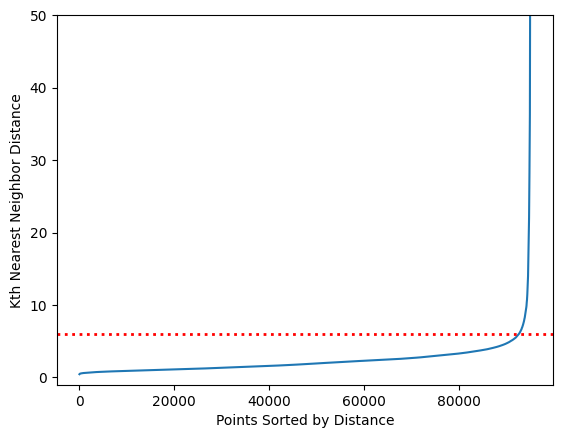

In [10]:
# 1. Set k to your min_samples value
k = min_samples

# 2. Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# 3. Sort distances by the k-th neighbor column (index k-1)
sorted_distances = np.sort(distances[:, k-1])

# 4. Plot to find the Epsilon elbow
plt.plot(sorted_distances)
plt.ylabel("Kth Nearest Neighbor Distance")
plt.xlabel("Points Sorted by Distance")
plt.ylim(bottom=-1, top=50)
plt.axhline(y=6, linestyle=':', color='red', linewidth=2)
None

In [11]:
eps = 6.0

I initially tried 8.7 but it resulted in the following breakdown of clusters:

--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---

 cluster  cluster_size  positive_count  positive_rate

      -1            13               6       0.461538

       0         55377            5115       0.092367

       1          1557              56       0.035967


The positive class are clearly hidden in the large cluster. I hypothesize the mixed data (mostly binary and some numeric is causing issues for euclidian distance)

I will try use gower instead which handles mixed types

In [17]:
# 1. Compute the custom distance matrix across your mixed data
# (Expects a pandas DataFrame or numpy array where columns are mixed)
distance_matrix = gower.gower_matrix(X_scaled)

KeyboardInterrupt: 

In [14]:
# Fit NearestNeighbors using the 'precomputed' Gower matrix
# We use k+1 because the closest neighbor to any point is always itself (distance 0)
neighbors = NearestNeighbors(n_neighbors=k+1, metric='precomputed')
neighbors_fit = neighbors.fit(distance_matrix)
distances, indices = neighbors_fit.kneighbors(distance_matrix)

# Grab the distance to the k-th nearest neighbor and sort
k_distances = np.sort(distances[:, k])

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Data Points (Sorted by Distance)')
plt.ylabel(f'{k}-th Nearest Neighbor Gower Distance')
plt.title('Elbow Method for Selecting DBSCAN eps')
plt.grid(True)
None

KeyboardInterrupt: 

In [16]:
# clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
clustering = DBSCAN(eps=0.05, min_samples=min_samples, metric='precomputed').fit(X_scaled)

ValueError: Negative values in data passed to X.

In [ ]:
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 1
Estimated number of noise points: 1246


In [104]:
# Convert X to pandas df for easier aggregation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns).copy()

In [105]:
# Combine cluster labels and target variable into a single summary DataFrame
summary_df = pd.DataFrame({"cluster": labels, "target": y_resampled})

In [106]:
# --- 3. Aggregate Cluster Statistics ---
cluster_stats = (
    summary_df.groupby("cluster")
    .agg(
        cluster_size=("target", "count"),
        positive_count=("target", "sum"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

In [107]:
# Global metrics for context
global_pos_rate = y.mean()
print(f"Total Data Points: {len(X_scaled_df)}")
print(f"Global Positive Rate: {global_pos_rate:.4f}")
print(
    f"Number of Clusters (excluding noise): {len(set(labels)) - (1 if -1 in labels else 0)}"
)

Total Data Points: 95095
Global Positive Rate: 0.0001
Number of Clusters (excluding noise): 1


In [108]:
# --- 4. Identify Target-Rich Clusters ---
# Sort by highest concentration of your positive target class
high_purity_clusters = cluster_stats.sort_values(
    by="positive_rate", ascending=False
).head(10)
print("\n--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---")
print(high_purity_clusters.to_string(index=False))


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
      -1          1246               3       0.002408
       0         93849              92       0.000980


In [136]:
# --- 5. Identify Popular Clusters ---
# Sort by size to find the largest groups (excluding noise cluster -1)
popular_clusters = (
    cluster_stats[cluster_stats["cluster"] != -1]
    .sort_values(by="cluster_size", ascending=False)
    .head(10)
)
print("\n--- TOP 10 LARGEST VALID CLUSTERS ---")
print(popular_clusters.to_string(index=False))


--- TOP 10 LARGEST VALID CLUSTERS ---
 cluster  cluster_size  positive_count  positive_rate
       0          7335               7       0.000954
       1           784              60       0.076531
       2           364               0       0.000000


In [137]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = popular_clusters.iloc[0]["cluster"]

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 0.0 ---
                               Cluster Mean   Global Mean  Difference
ProcessingMethod                  -0.024540 -7.183183e-17   -0.024540
BorrowerState                      0.011793 -8.886413e-18    0.011793
LoanStatus                         0.283552 -5.331848e-17    0.283552
Term                              -0.039632  1.199666e-16   -0.039632
InitialApprovalAmount             -0.139838 -9.923161e-17   -0.139838
CurrentApprovalAmount             -0.139535 -1.658797e-16   -0.139535
ServicingLenderState              -0.001833 -4.146993e-17   -0.001833
RuralUrbanIndicator               -0.011414  1.077478e-16   -0.011414
HubzoneIndicator                  -0.027579 -4.739420e-17   -0.027579
LMIIndicator                      -0.028030 -1.999443e-17   -0.028030
BusinessAgeDescription            -0.003442 -1.303341e-16   -0.003442
ProjectState                       0.011793 -8.886413e-18    0.011793
JobsReported                      -0.1452

In [138]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 0.0 ---
|--- ForgivenPercentage <= -2.48
|   |--- ForgivenessDate_int <= 0.35
|   |   |--- LoanStatusDate_int <= 0.15
|   |   |   |--- class: 0
|   |   |--- LoanStatusDate_int >  0.15
|   |   |   |--- class: 0
|   |--- ForgivenessDate_int >  0.35
|   |   |--- class: 1
|--- ForgivenPercentage >  -2.48
|   |--- NonProfit <= 1.84
|   |   |--- PAYROLL_PROCEED_pct <= -1.59
|   |   |   |--- class: 0
|   |   |--- PAYROLL_PROCEED_pct >  -1.59
|   |   |   |--- class: 1
|   |--- NonProfit >  1.84
|   |   |--- class: 0



In [139]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = 1

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 1 ---
                               Cluster Mean   Global Mean  Difference
ProcessingMethod                   0.933529 -7.183183e-17    0.933529
BorrowerState                     -0.091943 -8.886413e-18   -0.091943
LoanStatus                        -2.437755 -5.331848e-17   -2.437755
Term                               0.992664  1.199666e-16    0.992664
InitialApprovalAmount             -0.232948 -9.923161e-17   -0.232948
CurrentApprovalAmount             -0.233551 -1.658797e-16   -0.233551
ServicingLenderState               0.052674 -4.146993e-17    0.052674
RuralUrbanIndicator                0.162449  1.077478e-16    0.162449
HubzoneIndicator                   0.034576 -4.739420e-17    0.034576
LMIIndicator                      -0.022827 -1.999443e-17   -0.022827
BusinessAgeDescription            -0.185984 -1.303341e-16   -0.185984
ProjectState                      -0.091943 -8.886413e-18   -0.091943
JobsReported                      -0.244255

In [143]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 1 ---
|--- ForgivenessAmount <= -0.64
|   |--- TOTAL_PROCEED <= 0.64
|   |   |--- NonProfit <= 1.84
|   |   |   |--- PAYROLL_PROCEED_pct <= -0.45
|   |   |   |   |--- TOTAL_PROCEED <= -0.49
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- TOTAL_PROCEED >  -0.49
|   |   |   |   |   |--- class: 0
|   |   |   |--- PAYROLL_PROCEED_pct >  -0.45
|   |   |   |   |--- LoanStatus <= -1.03
|   |   |   |   |   |--- PROCEED_Per_Job <= 2.96
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- PROCEED_Per_Job >  2.96
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- LoanStatus >  -1.03
|   |   |   |   |   |--- DateApproved_int <= 1.46
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- DateApproved_int >  1.46
|   |   |   |   |   |   |--- class: 1
|   |   |--- NonProfit >  1.84
|   |   |   |--- class: 0
|   |--- TOTAL_PROCEED >  0.64
|   |   |--- TOTAL_PROCEED <= 1.31
|   |   |   |--- ProcessingMethod <= 0.44
|   |   |   |